In [1]:
!kaggle datasets download salader/dogsvscats # to download the dataset from the kaggle

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:59<00:00, 19.3MB/s]



In [2]:
!unzip /content/dogsvscats.zip -d /content # it is used to unzip the .zip file


Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

# Feature Extraction
Use Feature Extraction when your dataset is small and/or similar to the data the pretrained model learned from.
Your data → normal photos of dogs and cats
The pretrained CNN already knows useful things like:
edges → textures → shapes → object parts
So you can mostly reuse those features.

In [3]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Flatten
from keras import Sequential
from keras.applications.vgg16 import VGG16

VGG-16 pretrained

      ↓
Conv Block 1

Conv Block 2

Conv Block 3

Conv Block 4

Conv Block 5

      ↓
Feature extraction

      ↓
Your own classifier


In [4]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False, # it means not incluse the fully conneted layers only keep the convolution layer
    input_shape = (150,150,3) # it can be anything beacuse we have already take the model weigh from the pretrained model.
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**here we add the Dense layer or fully connneted layer**

In [6]:
model = Sequential()
model.add(conv_base)# here we have added the already trained the conventionl layer
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

# Freeze the convolution layer
⚠️Freeze ≠ remove.
Freeze means:
Use the layer, but don't change its weights during training.

In [8]:
conv_base.trainable = False # here we have set the not to train the convolution layer only trained the fully connected layer

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**here u can can see the the non trainable parameters when we have set it False**

In [10]:
# import image folders from the directory
train_ds = keras.utils.image_dataset_from_directory(

directory = r'/content/train',# path
labels='inferred',
label_mode = 'int',
batch_size=32,#take 32 image at one time for training
image_size=(150,150))

validation_ds = keras.utils.image_dataset_from_directory(
directory = r'/content/test',#path
labels='inferred',
label_mode = 'int',
batch_size=32,
image_size=(150,150))

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [11]:
# Normalize the image
def process(image, label) :
    image = tensorflow.cast(image/255. ,tensorflow.float32)#tensorflow.cast() is used to change the data type of a TensorFlow tensor. image/255
    return image, label

train_ds = train_ds.map(process)#Apply the process() function to every image and label in the training dataset." it applied to all image of trainingset
validation_ds = validation_ds.map(process)#same as training set but on validation set

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

**If model have learned already the paramters then why to model.fit means train the model, why not direct prediction?**
The answer is the pretrained model like vgg16 have it output of 1000 classification image like cat,dog,chair, we have binary classes like cat and dog then classifcation then we have use the sigmoid activation and it pretrained model is trained on the softmax  and also the VGG16 pretrained on ImageNet has 1000 ImageNet categories like model.add(Dense(1000,activation='softmax')) 1000 output but u have to train ur own. so u have to train your model that model can learned your architecture.

In [13]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 131ms/step - accuracy: 0.8838 - loss: 0.2821 - val_accuracy: 0.9090 - val_loss: 0.2097
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9201 - loss: 0.1935 - val_accuracy: 0.9120 - val_loss: 0.2035
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.9321 - loss: 0.1656 - val_accuracy: 0.9106 - val_loss: 0.2100
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 142ms/step - accuracy: 0.9469 - loss: 0.1351 - val_accuracy: 0.9092 - val_loss: 0.2139
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9542 - loss: 0.1149 - val_accuracy: 0.9116 - val_loss: 0.2268
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9652 - loss: 0.0907 - val_accuracy: 0.9108 - val_loss: 0.2470
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.9724 - loss: 0.0716 - val_accuracy: 0.9032 - val_loss: 0.2909
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9778 - loss: 

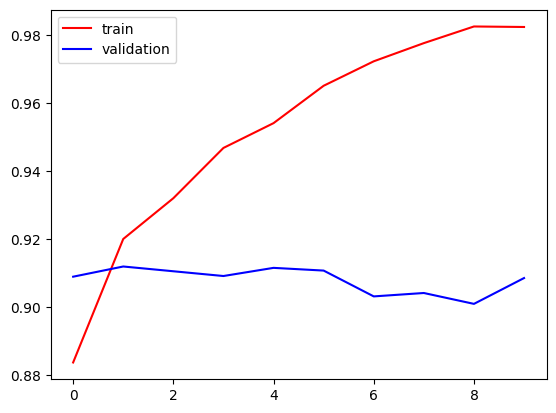

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

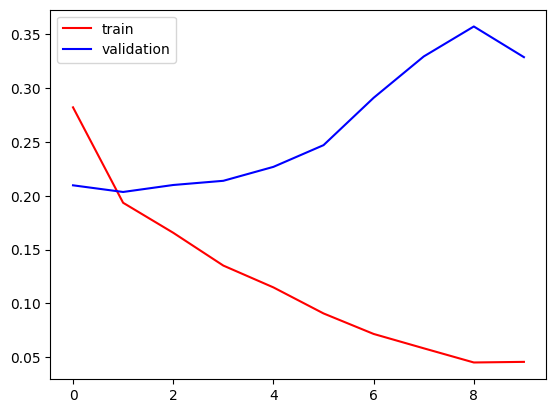

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

# Fine Tunning

In [16]:
# import image folders from the directory
train_ds_1 = keras.utils.image_dataset_from_directory(
directory = r'/content/train',# path
labels='inferred',
label_mode = 'int',
batch_size=32,
image_size=(150,150))

validation_ds_1 = keras.utils.image_dataset_from_directory(
directory = r'/content/test',#path
labels='inferred',
label_mode = 'int',
batch_size=32,
image_size=(150,150))

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [17]:
#Normalize the image
def process(image, label) :
    image = tensorflow.cast(image/255. ,tensorflow.float32)#tensorflow.cast() is used to change the data type of a TensorFlow tensor. image/255
    return image, label

train_ds_1 = train_ds_1.map(process)#Apply the process() function to every image and label in the training dataset." it applied to all image of trainingset
validation_ds_1 = validation_ds_1.map(process)#same as training set but on validation set

**convolutional Layer**

In [18]:
conv_base_1 = VGG16(
    weights = 'imagenet',
    include_top = False, # it means not incluse the fully conneted layers only keep the convolution layer
    input_shape = (150,150,3) # it can be anything beacuse we have already take the model weigh from the pretrained model.
)

In [19]:
conv_base_1.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Fully connneted layer**

In [20]:
model_1 = Sequential()
model_1.add(conv_base_1)# here we have added the already trained the conventionl layer
model_1.add(Flatten())
model_1.add(Dense(256,activation='relu'))
model_1.add(Dense(1,activation='sigmoid'))

In [21]:
model_1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

# Freeze some layers and some layer to train from the conv layer

In [22]:
conv_base_1.trainable = True

set_trainable = False

for layer in conv_base_1.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False



In [23]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [24]:
from keras.optimizers import RMSprop
model_1.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.0001),metrics=['accuracy'])
# by reasearch it proved that when fine tunning keep the learning_rate=too small

In [25]:
history_1 = model_1.fit(train_ds_1,epochs=10,validation_data=validation_ds_1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 159ms/step - accuracy: 0.9074 - loss: 0.2232 - val_accuracy: 0.9472 - val_loss: 0.1315
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9541 - loss: 0.1135 - val_accuracy: 0.9536 - val_loss: 0.1241
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.9771 - loss: 0.0663 - val_accuracy: 0.9226 - val_loss: 0.2499
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9862 - loss: 0.0396 - val_accuracy: 0.9562 - val_loss: 0.2030
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9916 - loss: 0.0253 - val_accuracy: 0.9516 - val_loss: 0.2840
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9546 - val_loss: 0.2560
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9951 - loss: 0.0180 - val_accuracy: 0.9496 - val_loss: 0.3007
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.9960 - loss:

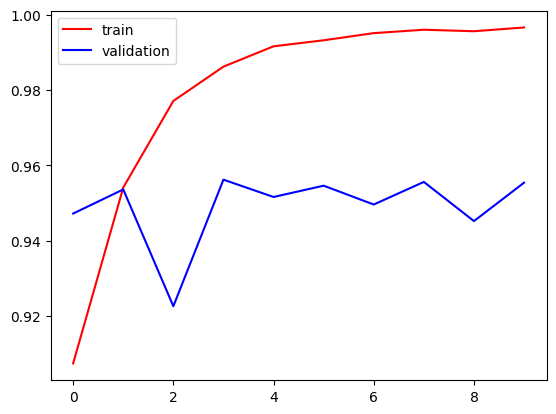

In [26]:
plt.plot(history_1.history['accuracy'],color='red',label='train')
plt.plot(history_1.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

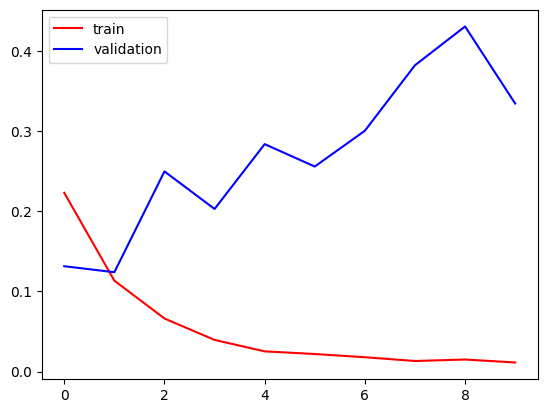

In [27]:
plt.plot(history_1.history['loss'],color='red',label='train')
plt.plot(history_1.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

# use data augmentation in the transfer learning

In [28]:
# import image folders from the directory
train_ds_2 = keras.utils.image_dataset_from_directory(
directory = r'/content/train',# path
labels='inferred',
label_mode = 'int',
batch_size=32,
image_size=(150,150))

validation_ds_2 = keras.utils.image_dataset_from_directory(
directory = r'/content/test',#path
labels='inferred',
label_mode = 'int',
batch_size=32,
image_size=(150,150))

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [29]:
#Normalize the image
def process(image, label) :
    image = tensorflow.cast(image/255. ,tensorflow.float32)#tensorflow.cast() is used to change the data type of a TensorFlow tensor. image/255
    return image, label

train_ds_2 = train_ds_2.map(process)#Apply the process() function to every image and label in the training dataset." it applied to all image of trainingset
validation_ds_2 = validation_ds_2.map(process)#same as training set but on validation set

In [30]:
conv_base_2 = VGG16(
    weights = 'imagenet',
    include_top = False, # it means not incluse the fully conneted layers only keep the convolution layer
    input_shape = (150,150,3) # it can be anything beacuse we have already take the model weigh from the pretrained model.
)

In [31]:
conv_base_2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Without padding="same", the feature map becomes too small (1×1), so a 3×3 filter cannot fit and Keras gives ValueError: Computed output size would be negative.**

**VGG16 gives 4×4×512 (4×4 spatial size with 512 learned feature maps, while the original image has 3 RGB channels); your Conv2D(32, 3×3) reduces it to 2×2×32, then MaxPooling2D reduces it to 1×1×32, causing the error.** u can see the error by remove the padding

In [32]:
from keras.layers import Conv2D,MaxPooling2D

model_2 = Sequential()
model_2.add(conv_base_2)# here we have added the already trained the conventionl layer

model_2.add(Conv2D(32, (3, 3),padding="same" , activation="relu"))
model_2.add(MaxPooling2D(padding="same"))

model_2.add(Conv2D(64, (3, 3), padding="same" ,activation="relu"))
model_2.add(MaxPooling2D(padding="same"))

model_2.add(Conv2D(128, (3, 3),padding="same" , activation="relu"))
model_2.add(MaxPooling2D(padding="same"))

model_2.add(Flatten())
model_2.add(Dense(256,activation='relu'))
model_2.add(Dense(1,activation='sigmoid'))

In [36]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 4, 4, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,260,932 (58.22 MB)

 Trainable params: 273,121 (1.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 273,123 (1.04 MB)

**MaxPooling2D() receives a 1×1×128 feature map, but its default 2×2 pooling window cannot fit inside 1×1, causing a negative-dimension error.use padding='same' in the Maxpooling**

In [33]:
conv_base_2.trainable = False # here we have set the not to train the convolution layer only trained the fully connected layer

In [34]:
from keras.optimizers import RMSprop
model_2.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.0001),metrics=['accuracy'])
# by reasearch it proved that when fine tunning keep the learning_rate=too small

In [35]:
history_2 = model_2.fit(train_ds_2,epochs=10,validation_data=validation_ds_2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 138ms/step - accuracy: 0.8609 - loss: 0.3210 - val_accuracy: 0.9028 - val_loss: 0.2302
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9071 - loss: 0.2257 - val_accuracy: 0.9098 - val_loss: 0.2130
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.9176 - loss: 0.2004 - val_accuracy: 0.9158 - val_loss: 0.2013
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9255 - loss: 0.1840 - val_accuracy: 0.9150 - val_loss: 0.2034
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 136ms/step - accuracy: 0.9317 - loss: 0.1698 - val_accuracy: 0.9180 - val_loss: 0.1960
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9402 - loss: 0.1497 - val_accuracy: 0.9124 - val_loss: 0.2147
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 141ms/step - accuracy: 0.9471 - loss: 0.1345 - val_accuracy: 0.9182 - val_loss: 0.2086
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.9576 - loss: 

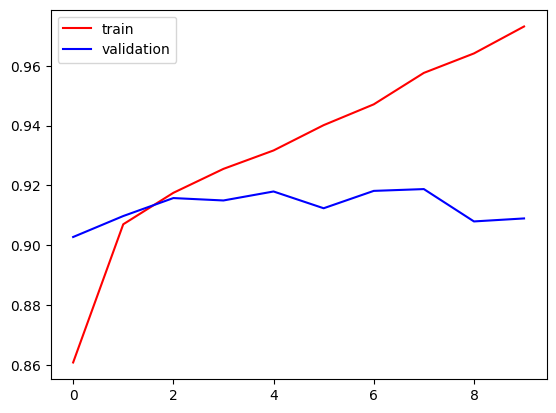

In [37]:
plt.plot(history_2.history['accuracy'],color='red',label='train')
plt.plot(history_2.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

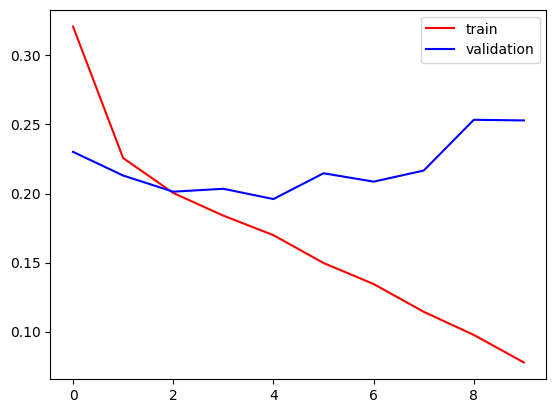

In [38]:
plt.plot(history_2.history['loss'],color='red',label='train')
plt.plot(history_2.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()